# Surface Smile Comparison — Best & Worst Dates

For each of four tickers (AAPL, VIX, F, TSLA) this notebook plots the **call** and **put** implied-volatility smiles
for the test date where the best VAE reconstructed the surface **best** and **worst** (by mean absolute error).

Each panel shows market IV (dashed) vs VAE reconstruction (solid) at a single maturity slice,
making it easy to see where the model tracks the market faithfully and where it falls short.

**Best model per ticker:**
| Ticker | Model |
|--------|-------|
| AAPL | MLP-log |
| VIX  | MLP     |
| F    | MLP-log |
| TSLA | MLP     |

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json

# ── locate project root ──────────────────────────────────────────────────────
def find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'pyproject.toml').exists() and (p / 'scripts').exists():
            return p
    raise RuntimeError('Project root not found')

ROOT = find_root(Path.cwd())
sys.path.insert(0, str(ROOT))
print('Project root:', ROOT)

Project root: c:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis


In [2]:
# ── configuration ────────────────────────────────────────────────────────────

TICKER_CFG = {
    'AAPL': {'model': 'mlp_log',  'label': 'AAPL (MLP-log)'},
    'VIX':  {'model': 'mlp',      'label': 'VIX (MLP)'},
    'F':    {'model': 'mlp_log',  'label': 'F — Ford (MLP-log)'},
    'TSLA': {'model': 'mlp',      'label': 'TSLA (MLP)'},
}

# Maturity index to use for the smile slice (index into days_grid)
# index 2 → 60 days; a nice near-term but not ultra-short slice
MAT_IDX = 2   # 60-day smile

COLORS = {
    'market_call': '#1f77b4',   # blue
    'market_put':  '#d62728',   # red
    'vae_call':    '#aec7e8',   # light blue
    'vae_put':     '#ffbb78',   # light orange
}

OUTPUT_DIR = ROOT / 'artifacts' / 'presentation'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Smile slice: maturity index {MAT_IDX}')
print(f'Output dir : {OUTPUT_DIR}')

Smile slice: maturity index 2
Output dir : c:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\presentation


In [3]:
# ── helpers ──────────────────────────────────────────────────────────────────

def load_ticker(ticker: str, model: str):
    """Load VAE and market surfaces plus grid metadata for a ticker/model pair."""
    surf_dir = ROOT / 'artifacts' / 'eval' / ticker / model / 'surfaces'
    vae  = np.load(surf_dir / 'vae_surfaces.npy')     # (N, 2, 11, 17)
    mkt  = np.load(surf_dir / 'market_surfaces.npy')  # (N, 2, 11, 17)
    dates = pd.read_csv(surf_dir / 'vae_surface_dates.csv')['date'].tolist()
    with open(surf_dir / 'grid_spec.json') as f:
        grid = json.load(f)
    return vae, mkt, dates, grid


def per_date_mae(vae, mkt):
    """Mean absolute error (vol pts) per date, ignoring NaNs."""
    return np.nanmean(np.abs(vae - mkt) * 100, axis=(1, 2, 3))


def smile_slice(arr, mat_idx, cp):
    """Extract a single smile: arr[date, cp, mat_idx, :] as %, handling NaN."""
    return arr[cp, mat_idx, :] * 100   # vol points


print('Helpers defined.')

Helpers defined.


In [4]:
# ── load all tickers ─────────────────────────────────────────────────────────

data = {}
for ticker, cfg in TICKER_CFG.items():
    vae, mkt, dates, grid = load_ticker(ticker, cfg['model'])
    mae = per_date_mae(vae, mkt)
    best_i  = int(np.argmin(mae))
    worst_i = int(np.argmax(mae))
    delta_pct = [round(d * 100) for d in grid['delta_grid']]
    days      = [int(d) for d in grid['days_grid']]
    data[ticker] = {
        'vae': vae, 'mkt': mkt, 'dates': dates, 'mae': mae,
        'best_i': best_i, 'worst_i': worst_i,
        'delta_pct': delta_pct, 'days': days,
    }
    print(f"{ticker:6s}  best: {dates[best_i]}  MAE={mae[best_i]:.2f} vp  "
          f"| worst: {dates[worst_i]}  MAE={mae[worst_i]:.2f} vp")

AAPL    best: 2025-08-26  MAE=0.48 vp  | worst: 2025-04-04  MAE=2.33 vp
VIX     best: 2025-07-17  MAE=3.51 vp  | worst: 2024-09-27  MAE=20.16 vp
F       best: 2024-11-13  MAE=2.57 vp  | worst: 2025-02-12  MAE=18.48 vp
TSLA    best: 2025-04-28  MAE=1.12 vp  | worst: 2024-10-02  MAE=6.72 vp


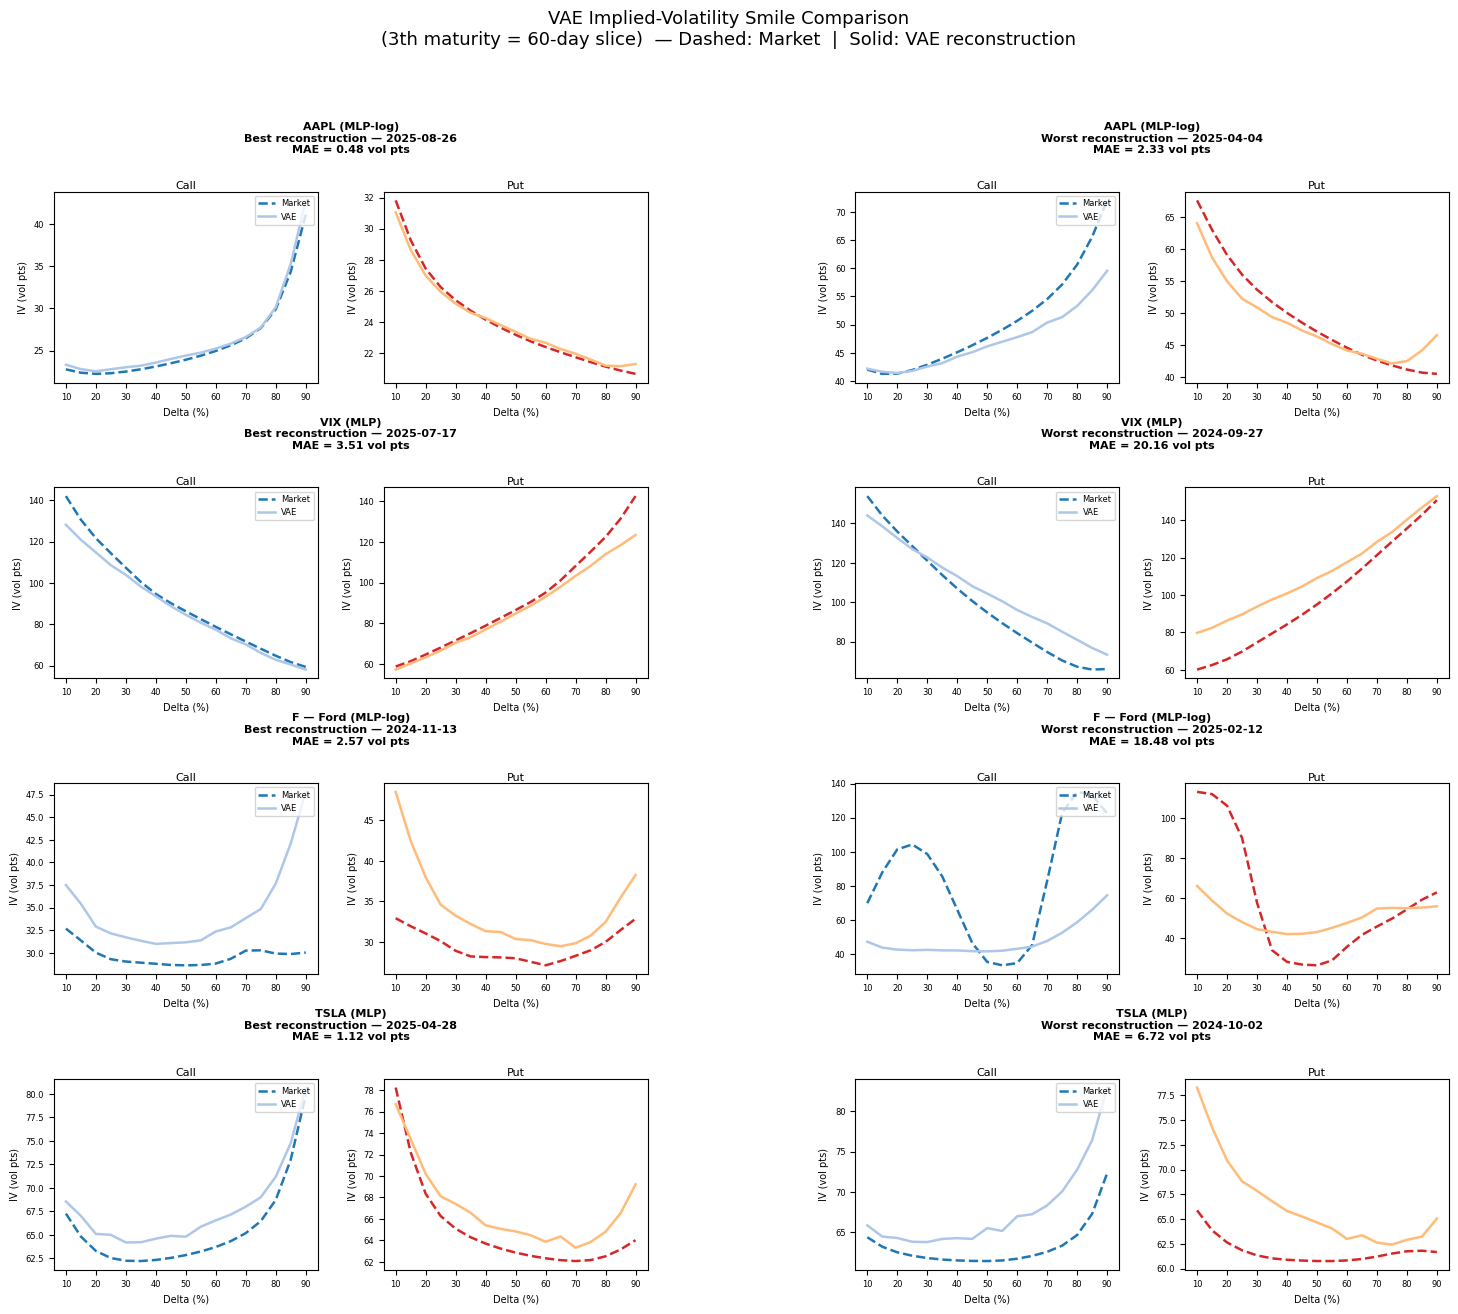

Saved: c:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\presentation\smile_comparison_best_worst.png


In [5]:
# ── main figure: 4 tickers × 2 cases (best/worst) × smile panels ────────────
# Layout: 4 rows (one per ticker), 4 columns (best-call, best-put, worst-call, worst-put)

TICKERS = ['AAPL', 'VIX', 'F', 'TSLA']
CASES   = ['best', 'worst']
CP_LABELS = ['Call smile', 'Put smile']
CASE_TITLES = ['Best reconstruction', 'Worst reconstruction']

fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    f'VAE Implied-Volatility Smile Comparison\n'
    f'({MAT_IDX+1}th maturity = {data["AAPL"]["days"][MAT_IDX]}-day slice)  '
    f'— Dashed: Market  |  Solid: VAE reconstruction',
    fontsize=13, y=1.01
)

outer = gridspec.GridSpec(4, 2, figure=fig, hspace=0.55, wspace=0.35)

for row, ticker in enumerate(TICKERS):
    d = data[ticker]
    delta_x = d['delta_pct']
    mat_day  = d['days'][MAT_IDX]

    for col, (case, case_title) in enumerate(zip(CASES, CASE_TITLES)):
        idx = d['best_i'] if case == 'best' else d['worst_i']
        date_str = d['dates'][idx]
        mae_val  = d['mae'][idx]

        inner = gridspec.GridSpecFromSubplotSpec(
            1, 2, subplot_spec=outer[row, col], wspace=0.25
        )

        for cp_idx, (cp_label, mkt_color, vae_color) in enumerate([
            ('Call', COLORS['market_call'], COLORS['vae_call']),
            ('Put',  COLORS['market_put'],  COLORS['vae_put']),
        ]):
            ax = fig.add_subplot(inner[0, cp_idx])

            mkt_smile = d['mkt'][idx, cp_idx, MAT_IDX, :] * 100
            vae_smile = d['vae'][idx, cp_idx, MAT_IDX, :] * 100

            # mask NaN
            mask = ~np.isnan(mkt_smile)
            ax.plot(np.array(delta_x)[mask], mkt_smile[mask],
                    '--', color=mkt_color, lw=1.8, label='Market')
            ax.plot(np.array(delta_x)[mask], vae_smile[mask],
                    '-',  color=vae_color, lw=1.8, label='VAE')

            ax.set_xlabel('Delta (%)', fontsize=7)
            ax.set_ylabel('IV (vol pts)', fontsize=7)
            ax.tick_params(labelsize=6)
            ax.set_title(f'{cp_label}', fontsize=8, pad=2)
            if cp_idx == 0:
                ax.legend(fontsize=6, loc='upper right')

        # Group label: ticker + case
        ticker_label = TICKER_CFG[ticker]['label']
        col_label = (
            f"{ticker_label}\n"
            f"{case_title} — {date_str}\n"
            f"MAE = {mae_val:.2f} vol pts"
        )
        # Add text above the inner grid via a hidden axis
        ax_title = fig.add_subplot(outer[row, col])
        ax_title.set_axis_off()
        ax_title.set_title(col_label, fontsize=8, fontweight='bold', pad=28)

plt.savefig(OUTPUT_DIR / 'smile_comparison_best_worst.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', OUTPUT_DIR / 'smile_comparison_best_worst.png')

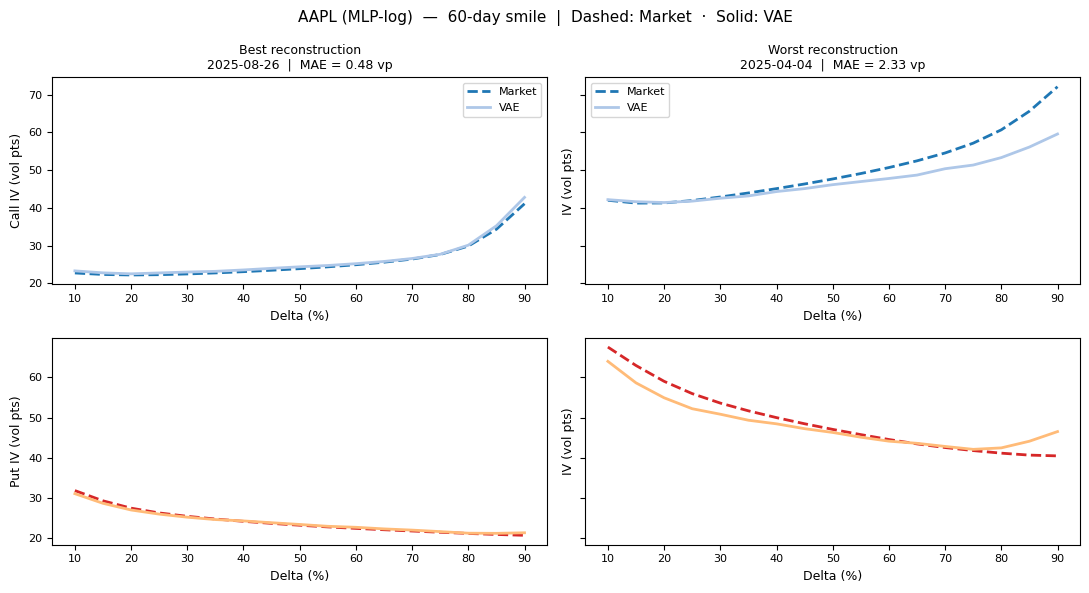

Saved: c:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\presentation\smile_AAPL_best_worst.png


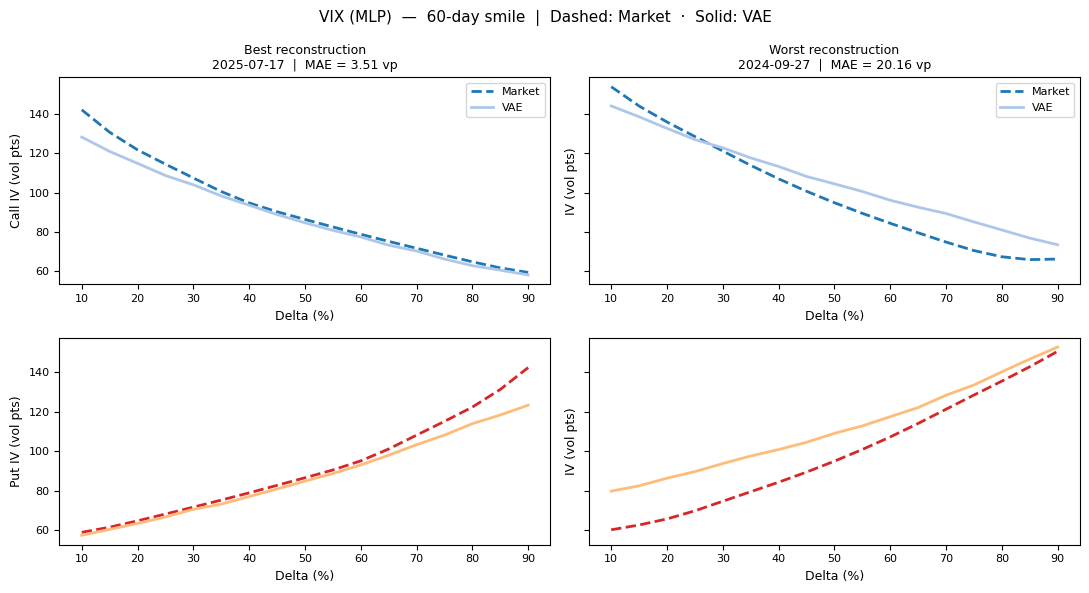

Saved: c:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\presentation\smile_VIX_best_worst.png


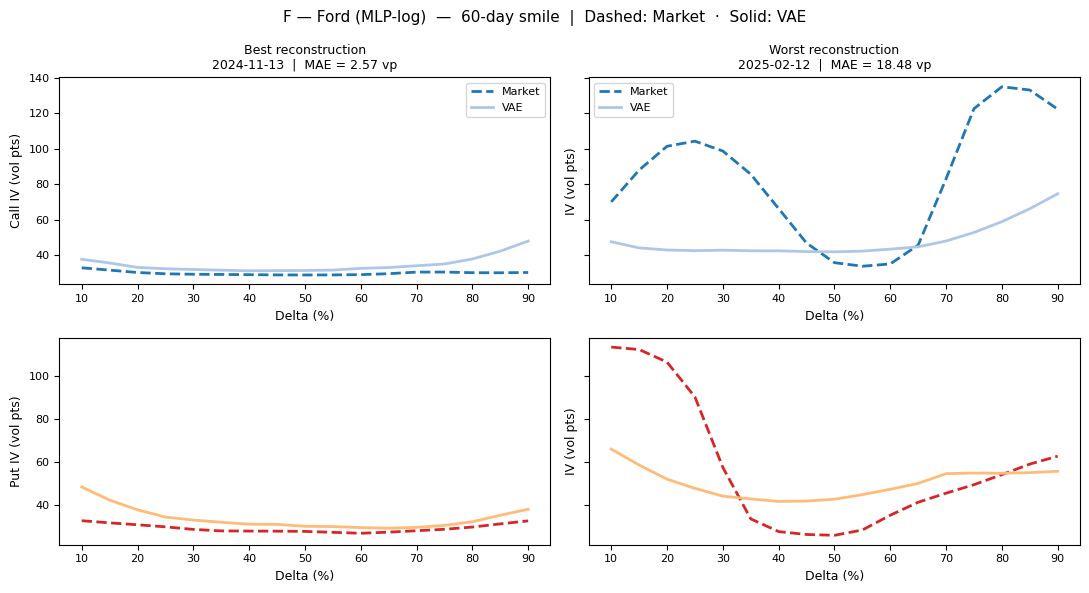

Saved: c:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\presentation\smile_F_best_worst.png


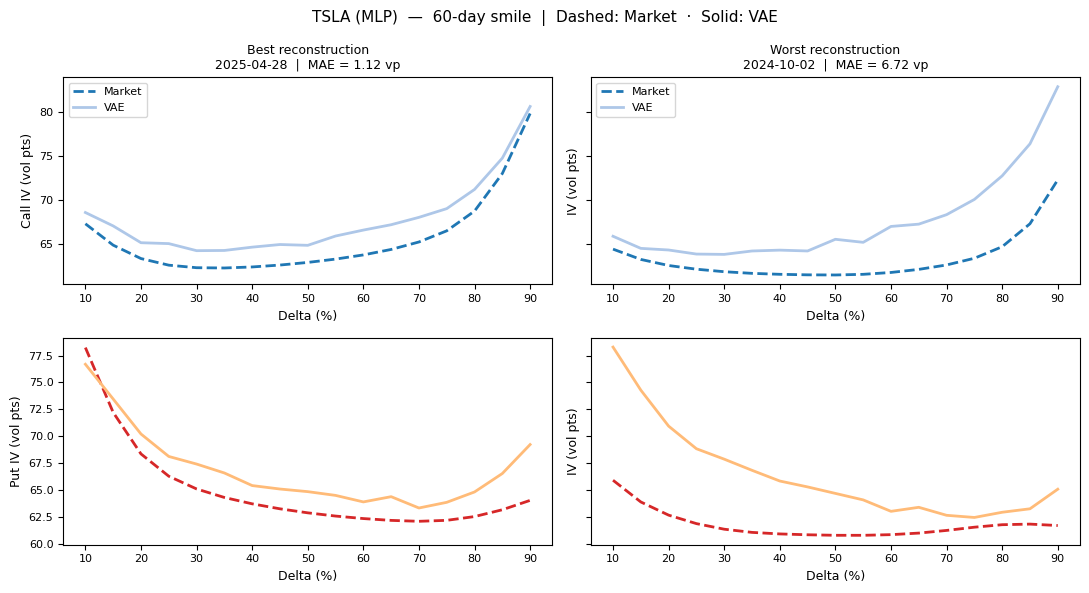

Saved: c:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\presentation\smile_TSLA_best_worst.png


In [6]:
# ── per-ticker standalone figures (one per ticker, best + worst side by side) ─
# Cleaner for embedding individual slides.

for ticker in TICKERS:
    d = data[ticker]
    delta_x  = d['delta_pct']
    mat_day  = d['days'][MAT_IDX]
    cfg_label = TICKER_CFG[ticker]['label']

    fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharey='row')
    fig.suptitle(
        f'{cfg_label}  —  {mat_day}-day smile  |  Dashed: Market  ·  Solid: VAE',
        fontsize=11
    )

    for col, (case, case_title) in enumerate(zip(CASES, CASE_TITLES)):
        idx      = d['best_i'] if case == 'best' else d['worst_i']
        date_str = d['dates'][idx]
        mae_val  = d['mae'][idx]

        for cp_idx, (cp_label, mkt_color, vae_color) in enumerate([
            ('Call', COLORS['market_call'], COLORS['vae_call']),
            ('Put',  COLORS['market_put'],  COLORS['vae_put']),
        ]):
            ax = axes[cp_idx, col]

            mkt_smile = d['mkt'][idx, cp_idx, MAT_IDX, :] * 100
            vae_smile = d['vae'][idx, cp_idx, MAT_IDX, :] * 100
            mask = ~np.isnan(mkt_smile)

            ax.plot(np.array(delta_x)[mask], mkt_smile[mask],
                    '--', color=mkt_color, lw=2, label='Market')
            ax.plot(np.array(delta_x)[mask], vae_smile[mask],
                    '-',  color=vae_color, lw=2, label='VAE')

            ax.set_xlabel('Delta (%)', fontsize=9)
            ax.set_ylabel('IV (vol pts)', fontsize=9)
            ax.tick_params(labelsize=8)

            if cp_idx == 0:
                ax.set_title(
                    f'{case_title}\n{date_str}  |  MAE = {mae_val:.2f} vp',
                    fontsize=9
                )
                ax.legend(fontsize=8)

            row_label = f'{cp_label} IV'
            if col == 0:
                ax.set_ylabel(f'{cp_label} IV (vol pts)', fontsize=9)

    plt.tight_layout()
    fname = OUTPUT_DIR / f'smile_{ticker}_best_worst.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

In [7]:
# ── summary table ─────────────────────────────────────────────────────────────

rows = []
for ticker in TICKERS:
    d   = data[ticker]
    cfg = TICKER_CFG[ticker]
    for case in ['best', 'worst']:
        idx = d['best_i'] if case == 'best' else d['worst_i']
        rows.append({
            'Ticker':  ticker,
            'Model':   cfg['model'],
            'Case':    case,
            'Date':    d['dates'][idx],
            'MAE (vp)': round(d['mae'][idx], 3),
            'Maturity slice (days)': d['days'][MAT_IDX],
        })

summary = pd.DataFrame(rows)
summary.to_csv(OUTPUT_DIR / 'smile_comparison_summary.csv', index=False)
print(summary.to_string(index=False))

Ticker   Model  Case       Date  MAE (vp)  Maturity slice (days)
  AAPL mlp_log  best 2025-08-26     0.480                     60
  AAPL mlp_log worst 2025-04-04     2.326                     60
   VIX     mlp  best 2025-07-17     3.510                     60
   VIX     mlp worst 2024-09-27    20.157                     60
     F mlp_log  best 2024-11-13     2.574                     60
     F mlp_log worst 2025-02-12    18.483                     60
  TSLA     mlp  best 2025-04-28     1.117                     60
  TSLA     mlp worst 2024-10-02     6.722                     60
